# RoBERTa Model

### Imports

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 34.2 MB/s eta 0:00:00


In [2]:
from transformers import (
    RobertaTokenizer,
    RobertaForMaskedLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
    RobertaForSequenceClassification,
    set_seed,
)
from datasets import load_dataset, Value
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
import optuna

### Set Seeds

In [3]:
# For consistency in training
SEED = 42
set_seed(SEED)

### Pre-Training on Corpus

In [4]:
# Loading model and tokenizer
roberta_model_mlm = RobertaForMaskedLM.from_pretrained('roberta-base').to('cuda')
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
# Load dataset
pretrained_dataset = load_dataset('avanishd/ground-news-2026')
print(pretrained_dataset)

README.md:   0%|          | 0.00/679 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/395k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/375k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8642 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1884 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 1836
    })
})


In [6]:
# Filter out any null summaries
pretrained_dataset = pretrained_dataset.filter(lambda dataset: dataset['summary'] != 'null' and dataset['summary'] is not None and dataset['summary'] != '')
print(pretrained_dataset)

Filter:   0%|          | 0/8642 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1884 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 1836
    })
})


In [7]:
# Determines tokenization per data
def tokenize(data):
    return roberta_tokenizer(data['summary'], truncation=True, max_length=512, padding='max_length')

In [8]:
# Example output of tokenizer
print(roberta_tokenizer("The father had two sons, the sons committed sins.", truncation=True, max_length=512, padding='max_length'))

{'input_ids': [0, 133, 1150, 56, 80, 7250, 6, 5, 7250, 2021, 29469, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [9]:
# Tokenizes the descriptions for RoBERTa training and remove unneccessary columns
tokenized_pretrained_dataset = pretrained_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'bias', 'headline', 'ground_news_interest_url'])
print(tokenized_pretrained_dataset)

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 1836
    })
})


In [10]:
# Used to mask random tokens
data_collator = DataCollatorForLanguageModeling(tokenizer=roberta_tokenizer, mlm=True, mlm_probability=0.15)

# Parameters used for trainer
training_args = TrainingArguments(
    output_dir='./domain-roberta-mlm',
    save_steps=10000,
    eval_strategy="epoch",
    save_total_limit=2,
    logging_steps=500,
    num_train_epochs=15,
    per_device_train_batch_size=8,
    learning_rate=5e-5,
    fp16=True
)

trainer = Trainer(model=roberta_model_mlm,
                  args=training_args,
                  data_collator=data_collator,
                  train_dataset=tokenized_pretrained_dataset['train'],
                  eval_dataset=tokenized_pretrained_dataset['validation'])

In [11]:
trainer.train() # Training

Epoch,Training Loss,Validation Loss
1,1.423382,1.253388
2,1.271449,1.213120
3,1.189296,1.133357
4,1.080804,1.068762
5,1.016530,1.061072
6,0.959233,1.031777
7,0.903236,0.987123
8,0.848151,0.959763
9,0.813611,0.944374
10,0.757826,0.882410


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=16215, training_loss=0.9110140771951125, metrics={'train_runtime': 1510.656, 'train_samples_per_second': 85.81, 'train_steps_per_second': 10.734, 'total_flos': 3.412710200706048e+16, 'train_loss': 0.9110140771951125, 'epoch': 15.0})

In [12]:
train_losses = [x['loss'] for x in trainer.state.log_history if 'loss' in x]
eval_losses = [x["eval_loss"] for x in trainer.state.log_history if "eval_loss" in x]

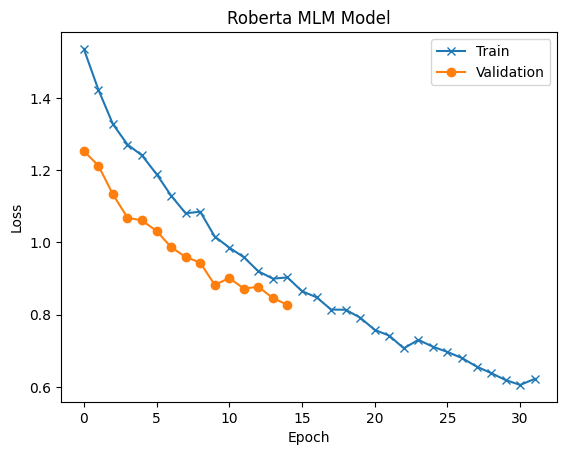

In [13]:
plt.plot(train_losses, label="Train", marker="x")
plt.plot(eval_losses, label="Validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Roberta MLM Model")
plt.show()

In [14]:
# Saving model
roberta_model_mlm.save_pretrained('./domain-roberta-mlm')
roberta_tokenizer.save_pretrained('./domain-roberta-mlm')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./domain-roberta-mlm/tokenizer_config.json',
 './domain-roberta-mlm/tokenizer.json')

### Data Preprocessing for Classification

In [15]:
# Load dataset
classifier_dataset = load_dataset('avanishd/ground-news-2026')

In [16]:
# Filter out any null summaries
classifier_dataset = classifier_dataset.filter(lambda dataset: dataset['summary'] != 'null' and dataset['summary'] is not None and dataset['summary'] != '')

### Train for Classification (With Base Model)

In [17]:
# IMPORTANT, reassign roberta_tokenizer so tokenize function uses the correct tokenizer
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

In [18]:
# Tokenizes the descriptions for RoBERTa training
tokenized_classifier_dataset_base = classifier_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'headline', 'ground_news_interest_url'])

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

In [19]:
# Rename column from bias to labels
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.rename_column('bias', 'labels')

# Map label strings to integers
label_map = {"Far Left": 0, "Left": 1, "Lean Left": 2, "Center": 3, "Lean Right": 4, "Right": 5, "Far Right": 6}
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.map(lambda dataset: {'labels': int(label_map[dataset['labels']])})
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.cast_column('labels', Value('int32'))

print(tokenized_classifier_dataset_base)
print(tokenized_classifier_dataset_base['train']['labels'])

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8642 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1884 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1836
    })
})
Column([2, 1, 1, 1, 1])


In [20]:
# Trial Evaluation Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "mae": mean_absolute_error(labels, preds),
    }

In [21]:
def roberta_base_objective(trial):
    total_steps = len(tokenized_classifier_dataset_base['train'])

    learning_rate = trial.suggest_float("learning_rate", low=1e-6, high=5e-5, log=True)
    per_device_train_batch_size = trial.suggest_categorical("per_device_batch_size", [8, 16, 32])
    num_train_epochs = trial.suggest_int("num_train_epochs", low=1, high=7)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.3)
    warmup_steps = trial.suggest_float("warmup_steps", 0.0, int(total_steps * 0.2))
    label_smoothing_factor = trial.suggest_float("label_smoothing_factor", 0.0, 0.2)

    # Reload fresh model per trial
    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=7).to('cuda')

    # Parameters used for trainer
    training_args = TrainingArguments(
            output_dir=f'./domain-roberta-classifier-base-trial-{trial.number}',
            save_strategy='epoch',
            eval_strategy='epoch',
            logging_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1_macro',
            greater_is_better=True,
            num_train_epochs=num_train_epochs,
            per_device_train_batch_size=per_device_train_batch_size,
            per_device_eval_batch_size=64,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            warmup_steps=warmup_steps,
            label_smoothing_factor=label_smoothing_factor,
            report_to='none',
            fp16=True
        )

    trainer = Trainer(model=model,
                  args=training_args,
                  train_dataset=tokenized_classifier_dataset_base['train'],
                  eval_dataset=tokenized_classifier_dataset_base['validation'],
                  compute_metrics=compute_metrics)

    trainer.train()

    eval_result = trainer.evaluate()
    return eval_result["eval_f1_macro"]

In [22]:
roberta_base_study = optuna.create_study(
    direction="maximize",
    study_name="roberta_base",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2),
)

[I 2026-03-16 01:20:16,310] A new study created in memory with name: roberta_base


In [23]:
roberta_base_study.optimize(roberta_base_objective, n_trials=5)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.846554,1.449872,0.422658,0.193761,1.251634
2,1.379286,1.231322,0.497277,0.348728,1.354031
3,1.178665,1.058972,0.587691,0.524263,0.949346
4,1.040589,0.989858,0.615468,0.551480,0.865468
5,0.975446,0.964038,0.639434,0.607690,0.828431
6,0.946896,0.951501,0.639434,0.597166,0.826797


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.934738,1.920885,0.266885,0.100786,1.598039


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

[I 2026-03-16 01:36:23,884] Trial 4 finished with value: 0.10078553890579244 and parameters: {'learning_rate': 1.994124270166725e-06, 'per_device_batch_size': 32, 'num_train_epochs': 1, 'weight_decay': 0.0954356222958906, 'warmup_steps': 667.0114583976297, 'label_smoothing_factor': 0.14582544810078904}. Best is trial 0 with value: 0.6069085213692862.


In [24]:
# Get best hyper parameters from optuna trial
best_params_base = roberta_base_study.best_trial.params
print(f"Best Base F1: {roberta_base_study.best_trial.value:.4f}")
print(f"Best Base params: {best_params_base}")

Best Base F1: 0.6069
Best Base params: {'learning_rate': 2.232262491920251e-06, 'per_device_batch_size': 8, 'num_train_epochs': 6, 'weight_decay': 0.06487968976638188, 'warmup_steps': 1629.1169059782342, 'label_smoothing_factor': 0.02665170451735408}


In [25]:
# Load base model
roberta_model_classifier_with_base = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=7).to('cuda')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
# Parameters used for trainer - automatically using Optuna best params
training_args_base = TrainingArguments(
        output_dir=f'./domain-roberta-classifier-base',
        save_strategy='epoch',
        eval_strategy='epoch',
        logging_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        num_train_epochs=best_params_base['num_train_epochs'],
        per_device_train_batch_size=best_params_base['per_device_batch_size'],
        per_device_eval_batch_size=64,
        learning_rate=best_params_base['learning_rate'],
        weight_decay=best_params_base['weight_decay'],
        warmup_steps=best_params_base['warmup_steps'],
        label_smoothing_factor=best_params_base['label_smoothing_factor'],
        fp16=True
    )

trainer_base = Trainer(model=roberta_model_classifier_with_base,
                args=training_args_base,
                train_dataset=tokenized_classifier_dataset_base['train'],
                eval_dataset=tokenized_classifier_dataset_base['validation'],
                compute_metrics=compute_metrics)

In [27]:
trainer_base.train() # Training

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.867100,1.495343,0.423203,0.206400,1.257625
2,1.328703,1.115147,0.571351,0.492450,0.974946
3,1.091411,0.993206,0.619826,0.571167,0.838235
4,0.988956,0.935270,0.632353,0.565811,0.811002
5,0.919372,0.909630,0.666667,0.634522,0.750000
6,0.886800,0.902358,0.665033,0.623768,0.753268


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=6486, training_loss=1.1803903641466957, metrics={'train_runtime': 379.1201, 'train_samples_per_second': 136.769, 'train_steps_per_second': 17.108, 'total_flos': 1.36434469100544e+16, 'train_loss': 1.1803903641466957, 'epoch': 6.0})

In [28]:
# Saving model
roberta_model_classifier_with_base.save_pretrained('./domain-roberta-classifier-base')
roberta_tokenizer.save_pretrained('./domain-roberta-classifier-base')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./domain-roberta-classifier-base/tokenizer_config.json',
 './domain-roberta-classifier-base/tokenizer.json')

### Evaluation

In [29]:
train_losses = [x['loss'] for x in trainer_base.state.log_history if 'loss' in x]
eval_losses = [x["eval_loss"] for x in trainer_base.state.log_history if "eval_loss" in x]

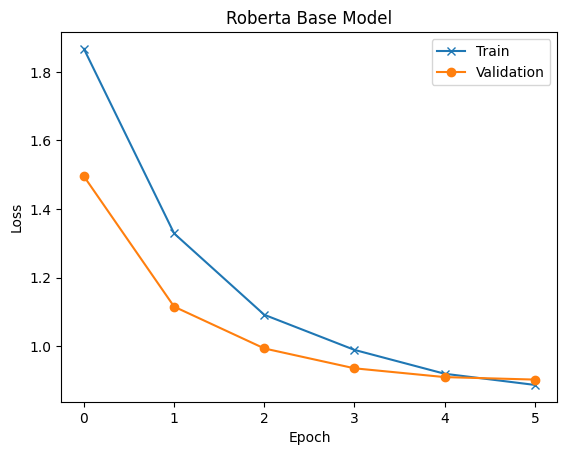

In [30]:
plt.plot(train_losses, label="Train", marker="x")
plt.plot(eval_losses, label="Validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Roberta Base Model")
plt.show()

In [31]:
# List of label names
label_names = ["Far Left", "Left", "Lean Left", "Center", "Lean Right", "Right", "Far Right"]

# Metric function, that will produce all needed metrics
def metric_runner(model: Trainer, data):
    predictions = model.predict(data['test'])
    preds = np.argmax(predictions.predictions, axis=-1)
    true_labels = predictions.label_ids

    print(f"Mean Absolule Error: {mean_absolute_error(true_labels, preds)}")
    print()
    print(classification_report(true_labels, preds, target_names=label_names))

    cm = confusion_matrix(true_labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot()
    plt.show()

Mean Absolule Error: 0.8259023354564756

              precision    recall  f1-score   support

    Far Left       0.81      0.91      0.86       166
        Left       0.57      0.55      0.56       231
   Lean Left       0.34      0.18      0.23       260
      Center       0.47      0.70      0.56       388
  Lean Right       0.99      0.97      0.98       393
       Right       0.44      0.25      0.32       275
   Far Right       0.63      0.79      0.70       171

    accuracy                           0.63      1884
   macro avg       0.61      0.62      0.60      1884
weighted avg       0.61      0.63      0.61      1884



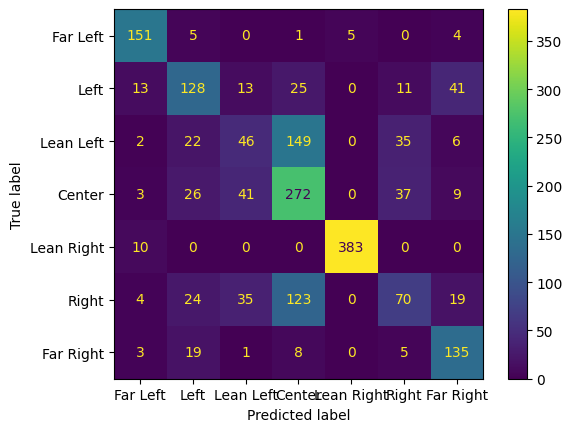

In [32]:
metric_runner(trainer_base, tokenized_classifier_dataset_base) # Get metrics and evaluation

### Train for Classification (With Pretrained Model)

In [33]:
# IMPORTANT, reassign roberta_tokenizer so tokenize function uses the correct tokenizer
roberta_tokenizer = RobertaTokenizer.from_pretrained('./domain-roberta-mlm')

In [34]:
# Tokenizes the descriptions for RoBERTa training
tokenized_classifier_dataset_pretrained = classifier_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'headline', 'ground_news_interest_url'])

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

In [35]:
# Rename column from bias to labels
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.rename_column('bias', 'labels')

# Map label strings to integers
label_map = {"Far Left": 0, "Left": 1, "Lean Left": 2, "Center": 3, "Lean Right": 4, "Right": 5, "Far Right": 6}
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.map(lambda dataset: {'labels': int(label_map[dataset['labels']])})
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.cast_column('labels', Value('int32'))

print(tokenized_classifier_dataset_pretrained)
print(tokenized_classifier_dataset_pretrained['train']['labels'])

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8642 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1884 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1836
    })
})
Column([2, 1, 1, 1, 1])


In [36]:
def roberta_pretrained_objective(trial):
    total_steps = len(tokenized_classifier_dataset_pretrained['train'])

    learning_rate = trial.suggest_float("learning_rate", low=1e-6, high=5e-5, log=True)
    per_device_train_batch_size = trial.suggest_categorical("per_device_batch_size", [8, 16, 32])
    num_train_epochs = trial.suggest_int("num_train_epochs", low=1, high=7)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.3)
    warmup_steps = trial.suggest_float("warmup_steps", 0.0, int(total_steps * 0.2))
    label_smoothing_factor = trial.suggest_float("label_smoothing_factor", 0.0, 0.2)

    # Reload fresh model per trial
    model = RobertaForSequenceClassification.from_pretrained('./domain-roberta-mlm', num_labels=7).to('cuda')

    # Parameters used for trainer
    training_args = TrainingArguments(
            output_dir=f'./domain-roberta-classifier-pretrained-trial-{trial.number}',
            save_strategy='epoch',
            eval_strategy='epoch',
            logging_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1_macro',
            greater_is_better=True,
            num_train_epochs=num_train_epochs,
            per_device_train_batch_size=per_device_train_batch_size,
            per_device_eval_batch_size=64,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            warmup_steps=warmup_steps,
            label_smoothing_factor=label_smoothing_factor,
            report_to='none',
            fp16=True
        )

    trainer = Trainer(model=model,
                  args=training_args,
                  train_dataset=tokenized_classifier_dataset_pretrained['train'],
                  eval_dataset=tokenized_classifier_dataset_pretrained['validation'],
                  compute_metrics=compute_metrics)

    trainer.train()

    eval_result = trainer.evaluate()
    return eval_result["eval_f1_macro"]

In [37]:
roberta_pretrained_study = optuna.create_study(
    direction="maximize",
    study_name="roberta_pretrained",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2),
)

[I 2026-03-16 01:42:54,197] A new study created in memory with name: roberta_pretrained


In [38]:
roberta_pretrained_study.optimize(roberta_pretrained_objective, n_trials=2)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: ./domain-roberta-mlm
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.943214,1.930337,0.226035,0.060379,1.497821
2,1.902620,1.788569,0.223312,0.052156,1.494553


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

[I 2026-03-16 01:50:44,011] Trial 1 finished with value: 0.7811208329031091 and parameters: {'learning_rate': 1.660057983119283e-05, 'per_device_batch_size': 8, 'num_train_epochs': 6, 'weight_decay': 0.016352430170064578, 'warmup_steps': 995.8371476987983, 'label_smoothing_factor': 0.07264335431321525}. Best is trial 1 with value: 0.7811208329031091.


In [39]:
# Get best hyper parameters from optuna trial for pretrained model
best_params_pretrained = roberta_pretrained_study.best_trial.params
print(f"Best Pretrained F1: {roberta_pretrained_study.best_trial.value:.4f}")
print(f"Best Pretrained params: {best_params_pretrained}")

Best Pretrained F1: 0.7811
Best Pretrained params: {'learning_rate': 1.660057983119283e-05, 'per_device_batch_size': 8, 'num_train_epochs': 6, 'weight_decay': 0.016352430170064578, 'warmup_steps': 995.8371476987983, 'label_smoothing_factor': 0.07264335431321525}


In [40]:
# Load base model
roberta_model_classifier_with_pretrained = RobertaForSequenceClassification.from_pretrained('./domain-roberta-mlm', num_labels=7).to('cuda')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: ./domain-roberta-mlm
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [41]:
# Parameters used for trainer - automatically using Optuna best params
training_args_pretrained = TrainingArguments(
        output_dir=f'./domain-roberta-classifier-pretrained',
        save_strategy='epoch',
        eval_strategy='epoch',
        logging_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        num_train_epochs=best_params_pretrained['num_train_epochs'],
        per_device_train_batch_size=best_params_pretrained['per_device_batch_size'],
        per_device_eval_batch_size=64,
        learning_rate=best_params_pretrained['learning_rate'],
        weight_decay=best_params_pretrained['weight_decay'],
        warmup_steps=best_params_pretrained['warmup_steps'],
        label_smoothing_factor=best_params_pretrained['label_smoothing_factor'],
        fp16=True
    )

trainer_pretrained = Trainer(model=roberta_model_classifier_with_pretrained,
                args=training_args_pretrained,
                train_dataset=tokenized_classifier_dataset_pretrained['train'],
                eval_dataset=tokenized_classifier_dataset_pretrained['validation'],
                compute_metrics=compute_metrics)

In [42]:
trainer_pretrained.train() # Training

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.474941,1.096231,0.605120,0.533562,0.890523
2,0.997124,0.975551,0.691176,0.668604,0.667211
3,0.790479,0.890553,0.752723,0.749185,0.494553
4,0.648397,0.929531,0.772876,0.765976,0.448257
5,0.554677,1.003955,0.785403,0.783656,0.424292
6,0.487077,1.039601,0.784314,0.782308,0.429739


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=6486, training_loss=0.8254492868805167, metrics={'train_runtime': 378.4837, 'train_samples_per_second': 136.999, 'train_steps_per_second': 17.137, 'total_flos': 1.36434469100544e+16, 'train_loss': 0.8254492868805167, 'epoch': 6.0})

In [43]:
# Saving model
roberta_model_classifier_with_pretrained.save_pretrained('./domain-roberta-classifier-pretrained')
roberta_tokenizer.save_pretrained('./domain-roberta-classifier-pretrained')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./domain-roberta-classifier-pretrained/tokenizer_config.json',
 './domain-roberta-classifier-pretrained/tokenizer.json')

### Evaluation

In [44]:
train_losses = [x['loss'] for x in trainer_pretrained.state.log_history if 'loss' in x]
eval_losses = [x["eval_loss"] for x in trainer_pretrained.state.log_history if "eval_loss" in x]

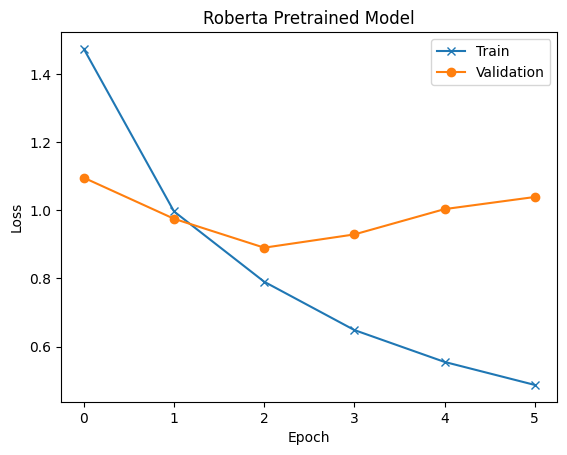

In [45]:
plt.plot(train_losses, label="Train", marker="x")
plt.plot(eval_losses, label="Validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Roberta Pretrained Model")
plt.show()

Mean Absolule Error: 0.4554140127388535

              precision    recall  f1-score   support

    Far Left       0.91      0.99      0.95       166
        Left       0.80      0.89      0.84       231
   Lean Left       0.56      0.52      0.54       260
      Center       0.68      0.67      0.68       388
  Lean Right       1.00      0.99      0.99       393
       Right       0.63      0.53      0.58       275
   Far Right       0.80      0.94      0.86       171

    accuracy                           0.78      1884
   macro avg       0.77      0.79      0.78      1884
weighted avg       0.77      0.78      0.77      1884



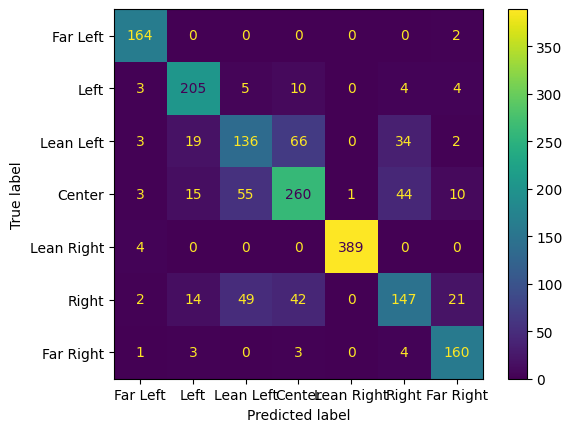

In [46]:
metric_runner(trainer_pretrained, tokenized_classifier_dataset_pretrained) # Get metrics and evaluation

### Check Significance of Results with Bootstrapping

In [47]:
def bootstrap_f1(y_true, y_pred_a, y_pred_b, n_boot=10000):
    rng = np.random.RandomState(42)
    n = len(y_true)
    boot_diffs = []

    a_score = f1_score(y_true, y_pred_a, average='macro')
    b_score = f1_score(y_true, y_pred_b, average='macro')
    score_diff = a_score - b_score

    for _ in range(n_boot):
        idex_list = rng.randint(0, n, size=n)

        f1_a = f1_score(y_true[idex_list], y_pred_a[idex_list], average="macro")
        f1_b = f1_score(y_true[idex_list], y_pred_b[idex_list], average="macro")

        boot_diffs.append(f1_a - f1_b)

    boot_diffs = np.array(boot_diffs)
    p_value = np.mean(boot_diffs <= 0)

    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)

    print("F1 Score A: ", a_score)
    print("F1 Score B: ", b_score)
    print("F1 Score Difference: ", score_diff)
    print("CI Lower: ", ci_lower)
    print("CI Upper: ", ci_upper)
    print("P Value: ", p_value)
    print("Significant: ", 0.0 < ci_lower or ci_upper < 0.0)

In [48]:
base_trainer = Trainer(RobertaForSequenceClassification.from_pretrained('./domain-roberta-classifier-base'))
pretrained_trainer = Trainer(RobertaForSequenceClassification.from_pretrained('./domain-roberta-classifier-pretrained'))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [49]:
base_predictions = base_trainer.predict(tokenized_classifier_dataset_base['test'])
base_preds = np.argmax(base_predictions.predictions, axis=-1)
true_labels = base_predictions.label_ids

pretrained_predictions = pretrained_trainer.predict(tokenized_classifier_dataset_pretrained['test'])
pretrained_preds = np.argmax(pretrained_predictions.predictions, axis=-1)

In [50]:
bootstrap_f1(true_labels, base_preds, pretrained_preds)

F1 Score A:  0.6030686183972378
F1 Score B:  0.7774145777435065
F1 Score Difference:  -0.17434595934626873
CI Lower:  -0.19674650320206
CI Upper:  -0.15211351092998976
P Value:  1.0
Significant:  True


### Upload the better model

Upload the model that boostrapping shows is better. We have always observed a statistically significant difference.

In [52]:
from google.colab import userdata
from huggingface_hub import login

# Retrieve token and login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

# Push the base model and tokenizer to Hugging face
roberta_model_classifier_with_pretrained.push_to_hub("avanishd/roberta-pretrained-ground-news")
roberta_tokenizer.push_to_hub("avanishd/roberta-pretrained-ground-news")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...372zilb/model.safetensors:   0%|          |  550kB /  499MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/avanishd/roberta-pretrained-ground-news/commit/011fe70a43c5083acc38af96def1bab9335f4e11', commit_message='Upload tokenizer', commit_description='', oid='011fe70a43c5083acc38af96def1bab9335f4e11', pr_url=None, repo_url=RepoUrl('https://huggingface.co/avanishd/roberta-pretrained-ground-news', endpoint='https://huggingface.co', repo_type='model', repo_id='avanishd/roberta-pretrained-ground-news'), pr_revision=None, pr_num=None)